# Chapter 3 — Basis, Dimension, and Coordinates

Chapter 2 ended at a boundary. Fewer than $n$ vectors in $\mathbb{R}^n$ can
never reach everywhere; more than $n$ always contain redundancy; and at exactly
$n$, a random set was both spanning and independent in all 2,000 trials.

A set with both properties is a **basis**, and it is the most important object
in this course. Here is why, in one sentence:

> A basis turns a vector space into a **coordinate system**: every vector gets
> a unique address, and every abstract space becomes $\mathbb{R}^n$ in disguise.

The consequence people underrate is the flip side. There are infinitely many
bases for any space, so every vector has infinitely many addresses, one per
basis. The vector never moves. **Choosing a basis is choosing a description**,
and a well-chosen description can make a hard problem trivial, which is the
entire trick behind data compression and behind most of what comes later in
this course.

| Module | What you build | Data |
|---|---|---|
| I | The **basis**, the Goldilocks set, and a proof-by-measurement that addresses are unique | — |
| II | **Dimension**: 500 random bases of the same plane, all the same size | — |
| III | **Coordinates** and the change-of-basis matrix; one vector drawn in two grids | — |
| IV | The same photo written in the **pixel basis and the cosine basis**, an order-of-magnitude difference in what it costs to store, plus a digit where the effect nearly vanishes | `uoft-cs/cifar10`, `ylecun/mnist` |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a few seconds on CPU. CIFAR-10 is a ~170 MB download the first
time, then cached. Assumes Chapters 1–2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — The Basis

## I.a Two conditions, both necessary

🧠 **The intuition.** You want a set of reference directions that is **big
enough to describe everything** and **small enough to have no waste**. Those are
exactly the two conditions from Chapter 2, and they pull in opposite directions:
adding vectors helps you span and hurts your independence.

- Too few vectors → they span only part of the space; some vectors have no address.
- Too many vectors → they span, but redundantly; some vectors have *several* addresses.
- Just right → every vector has exactly one address.

📐 **The math.** A set $B = \{\mathbf{b}_1, \dots, \mathbf{b}_n\} \subseteq V$
is a **basis** for $V$ if it is

1. **linearly independent**, and
2. **spanning**: $\text{span}(B) = V$.

The **standard basis** for $\mathbb{R}^n$ is $\mathbf{e}_1, \dots, \mathbf{e}_n$,
the columns of the identity matrix. It is so familiar that it is easy to forget
it is a choice: writing $\mathbf{v} = (3, 1)$ already means "3 units of
$\mathbf{e}_1$ plus 1 unit of $\mathbf{e}_2$".

💻 **The code.** Four candidate sets in $\mathbb{R}^3$, each failing or passing
for a different reason.

In [2]:
def basis_report(vectors, n_dim, name):
    """Check the two conditions and say which (if either) fails."""
    A = np.column_stack(vectors)
    k, r = A.shape[1], np.linalg.matrix_rank(A)
    independent, spanning = (r == k), (r == n_dim)
    verdict = "A BASIS" if (independent and spanning) else "not a basis"
    print(f"{name}: {k} vectors, rank {r}  ->  {verdict}")
    if not independent:
        print("    fails independence: some vector is a combination of the others")
    if not spanning:
        print(f"    fails spanning: reaches only a {r}-dimensional slice of R^{n_dim}")
    print()

basis_report([np.array([1., 0, 0]), np.array([0, 1., 0])], 3, "too few  (2 vectors)")
basis_report([np.array([1., 0, 0]), np.array([0, 1., 0]),
              np.array([0, 0, 1.]), np.array([1., 1., 1.])], 3, "too many (4 vectors)")
basis_report([np.array([1., 1, 0]), np.array([0, 1., 1.]), np.array([1., 0, 1.])], 3,
             "just right (3 vectors)")
basis_report([np.array([1., 1, 0]), np.array([0, 1., 1.]), np.array([1., 2., 1.])], 3,
             "3 vectors, but dependent")

too few  (2 vectors): 2 vectors, rank 2  ->  not a basis
    fails spanning: reaches only a 2-dimensional slice of R^3

too many (4 vectors): 4 vectors, rank 3  ->  not a basis
    fails independence: some vector is a combination of the others

just right (3 vectors): 3 vectors, rank 3  ->  A BASIS

3 vectors, but dependent: 3 vectors, rank 2  ->  not a basis
    fails independence: some vector is a combination of the others
    fails spanning: reaches only a 2-dimensional slice of R^3



The last two cases are the instructive pair: both have three vectors in
$\mathbb{R}^3$, and only one is a basis. **Counting is not checking.** The third
vector of the last set is the sum of the first two, so the set collapses onto a
plane and misses two of the three dimensions it was supposed to cover.

## I.b The property that makes a basis worth having

🧠 **The intuition.** An address system is only useful if every location has
exactly one address. Spanning guarantees each vector gets an address at all;
independence guarantees it never gets two, because two different recipes for
the same vector is exactly the redundancy that independence forbids.

📐 **The math.** If $B$ is a basis for $V$, then every $\mathbf{v} \in V$ can be
written as

$$ \mathbf{v} = c_1\mathbf{b}_1 + \cdots + c_n\mathbf{b}_n $$

in **exactly one way**. Spanning gives existence; independence gives uniqueness
(Chapter 2, §3.1). Existence *and* uniqueness together is what "address" means.

💻 **The code.** Test it the honest way: take a basis and a non-basis, throw a
thousand random targets at each, and check whether the reconstruction is exact
and whether the coefficients are forced.

In [3]:
def address_test(vectors, n_trials=1000, tol=1e-9):
    """For random targets: is the target reachable, and are the coefficients unique?"""
    A = np.column_stack(vectors)
    _, s, Vt = np.linalg.svd(A)
    s_full = np.zeros(Vt.shape[0]); s_full[:len(s)] = s
    null = Vt[s_full <= 1e-10].T                  # non-zero recipes for the zero vector
    reachable = 0
    for _ in range(n_trials):
        b = rng.normal(size=A.shape[0])
        c, *_ = np.linalg.lstsq(A, b, rcond=None)
        reachable += np.linalg.norm(A @ c - b) < tol
    unique = null.shape[1] == 0
    print(f"    reachable targets: {reachable/n_trials:>6.1%}   "
          f"addresses unique: {'yes' if unique else f'NO ({null.shape[1]}-parameter family)'}")

good = [np.array([1., 1, 0]), np.array([0, 1., 1.]), np.array([1., 0, 1.])]
few  = [np.array([1., 0, 0]), np.array([0, 1., 0])]
many = good + [np.array([1., 1., 1.])]

print("a basis:");            address_test(good)
print("too few vectors:");    address_test(few)
print("too many vectors:");   address_test(many)

a basis:
    reachable targets: 100.0%   addresses unique: yes
too few vectors:
    reachable targets:   0.0%   addresses unique: yes
too many vectors:
    reachable targets: 100.0%   addresses unique: NO (1-parameter family)


Three outcomes, and only one of them is useful. The basis reaches every target
and pins down the coefficients exactly. The undersized set reaches essentially
nothing, because a random point of $\mathbb{R}^3$ is almost never on a given
plane, so 0% of the targets came back reachable. The oversized set reaches
everything, but the address it gives is a one-parameter family, infinitely many
recipes for the same vector, exactly as in Chapter 2, §3.2. That is perfectly
fine if you only want to *reach* things, and useless if you want to *name* them.

---
# Module II — Dimension

## II.a Different bases, same size, always

🧠 **The intuition.** There are infinitely many bases for $\mathbb{R}^3$. Spin
the axes any way you like, stretch them, skew them. What never changes is that
you need **exactly three** vectors. That invariant number is the **dimension**,
and it is a property of the *space*, not of any particular basis.

📐 **The math.** Every basis of a finite-dimensional space $V$ has the same
number of elements; that number is $\dim V$. It follows that in an
$n$-dimensional space, any $n$ independent vectors automatically span (so they
form a basis), and any $n$ spanning vectors are automatically independent. Once
you have the right *count*, one condition implies the other.

💻 **The code.** Generate random bases of a plane in $\mathbb{R}^3$ and check
that no amount of randomness produces one of a different size.

In [4]:
N_BASES = 500        # <- knob

a1 = np.array([1.0, 1.0, 0.0])
a2 = np.array([0.0, 1.0, 1.0])
plane = np.column_stack([a1, a2])                 # a 2-D subspace of R^3

sizes = []
for _ in range(N_BASES):
    M = rng.normal(size=(2, 2))                   # random mix of a1 and a2...
    candidate = plane @ M                         # ...is another pair spanning the plane
    sizes.append(np.linalg.matrix_rank(candidate))

print(f"{N_BASES} randomly generated bases of the same plane")
print("distinct sizes observed:", sorted(int(x) for x in set(sizes)))
print("dim(plane) =", np.linalg.matrix_rank(plane), " dim(R^3) =", 3)
print("\nsome examples (each column is a basis vector):")
for _ in range(2):
    print(np.round(plane @ rng.normal(size=(2, 2)), 2), "\n")

500 randomly generated bases of the same plane
distinct sizes observed: [2]
dim(plane) = 2  dim(R^3) = 3

some examples (each column is a basis vector):
[[ 0.08 -0.63]
 [ 0.36  0.04]
 [ 0.27  0.67]] 

[[ 0.22 -0.88]
 [-0.25 -1.34]
 [-0.46 -0.46]] 



## II.b Dimension is not the number of components

This is the trap. A vector in that plane still has **three** components, because
it lives in $\mathbb{R}^3$. But the plane itself is **two**-dimensional: two
numbers are enough to say exactly where you are on it. The number of components
is a fact about the container; the dimension is a fact about the contents.

That distinction is the whole idea behind dimensionality reduction, and you
already measured an instance of it in Chapter 2, §4.2, where 500 digits stored
in 784 components occupied far fewer real directions.

In [5]:
c = rng.normal(size=2)
p = plane @ c                                     # a point on the plane

print("the point, in R^3 coordinates :", np.round(p, 3), " <- 3 components")
print("the point, in plane coordinates:", np.round(c, 3), " <- 2 numbers, no information lost")
print("rebuilt from 2 numbers:", np.round(plane @ c, 3))
print("\ndim of the plane:", np.linalg.matrix_rank(plane), "| components needed to store it in R^3: 3")

the point, in R^3 coordinates : [-0.842 -0.529  0.314]  <- 3 components
the point, in plane coordinates: [-0.842  0.314]  <- 2 numbers, no information lost
rebuilt from 2 numbers: [-0.842 -0.529  0.314]

dim of the plane: 2 | components needed to store it in R^3: 3


---
# Module III — Coordinates: A Vector's Address

## III.a The change-of-basis matrix

🧠 **The intuition.** "The vector $(3, 1)$" is shorthand. Written out, it means
*three steps along the first standard direction, one step along the second*. The
pair $(3,1)$ is not the vector. It is a set of **instructions relative to a
chosen basis**, and choosing different reference directions means the same arrow
needs different instructions.

📐 **The math.** Let $B = \{\mathbf{b}_1, \dots, \mathbf{b}_n\}$ be a basis and
let $B$ also denote the matrix with those vectors as columns. The **coordinate
vector** $[\mathbf{v}]_B$ is the unique $\mathbf{c}$ with

$$ \mathbf{v} = c_1\mathbf{b}_1 + \cdots + c_n\mathbf{b}_n = B\,\mathbf{c} $$

which gives the pair of conversions

$$ \boxed{\;\mathbf{v} = B\,[\mathbf{v}]_B \quad\text{and}\quad [\mathbf{v}]_B = B^{-1}\mathbf{v}\;} $$

The first is Chapter 2's column view: $B\mathbf{c}$ combines the basis vectors
using the coordinates. The second undoes it. **$B$ translates *out of* the basis
into standard coordinates; $B^{-1}$ translates *into* it.** Getting that
direction backwards is the most common error in this material, and the fix is to
remember that $B$'s columns are literally the basis vectors written in standard
coordinates.

💻 **The code.**

In [6]:
B = np.column_stack([np.array([2.0, 1.0]),        # b1
                     np.array([-1.0, 1.0])])      # b2
v = np.array([3.0, 1.0])                          # in STANDARD coordinates

coords = np.linalg.solve(B, v)                    # [v]_B  (solve, don't invert; see Chapter 6)
back = B @ coords

print("basis matrix B (columns are b1, b2):\n", B)
print("\nv in standard coordinates:", v)
print("v in B coordinates:       ", np.round(coords, 3))
print(f"    meaning: v = {coords[0]:.3f}·b1 + {coords[1]:.3f}·b2")
print("rebuilt B @ [v]_B:        ", np.round(back, 3))
print("\nthe standard basis is just B = I:", np.allclose(np.linalg.solve(np.eye(2), v), v))

basis matrix B (columns are b1, b2):
 [[ 2. -1.]
 [ 1.  1.]]

v in standard coordinates: [3. 1.]
v in B coordinates:        [ 1.333 -0.333]
    meaning: v = 1.333·b1 + -0.333·b2
rebuilt B @ [v]_B:         [3. 1.]

the standard basis is just B = I: True


## III.b The same vector, two grids

The picture makes the point better than any equation: **the arrow does not
move.** Only the grid we measure it against changes, and with it the numbers we
write down.

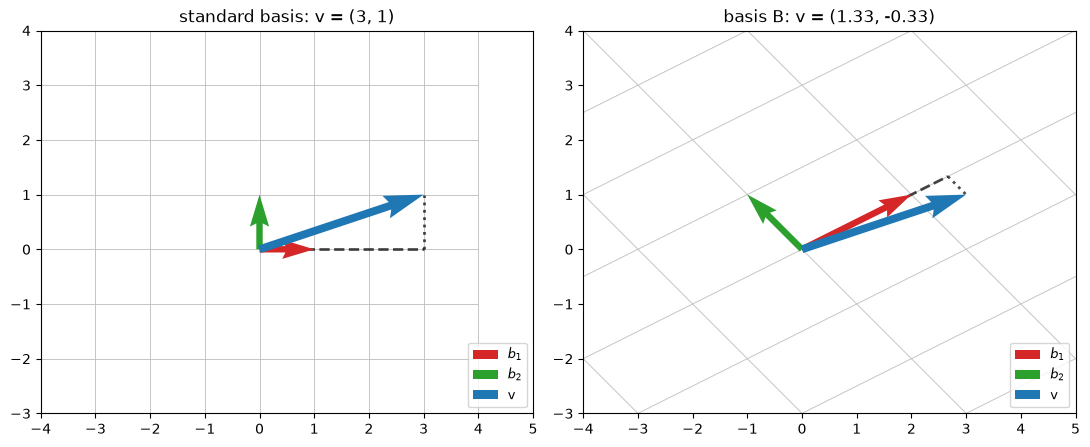

the arrow is identical in both panels; only the ruler changed


In [7]:
def draw_grid(ax, basis, color, lim=4, **kw):
    """Draw the lattice of integer combinations of the two basis vectors."""
    for i in range(-lim, lim + 1):
        p1 = basis @ np.array([i, -lim]); p2 = basis @ np.array([i, lim])
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=0.7, **kw)
        p1 = basis @ np.array([-lim, i]); p2 = basis @ np.array([lim, i])
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=0.7, **kw)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, basis, coords_, title in [
        (axes[0], np.eye(2), v, "standard basis: v = (3, 1)"),
        (axes[1], B, coords, f"basis B: v = ({coords[0]:.2f}, {coords[1]:.2f})")]:
    draw_grid(ax, basis, "0.75", alpha=0.9)
    for j, col in enumerate(["tab:red", "tab:green"]):
        ax.quiver(0, 0, *basis[:, j], angles="xy", scale_units="xy", scale=1,
                  color=col, width=0.013, zorder=4,
                  label=f"$e_{j+1}$" if basis is np.eye(2) else f"$b_{j+1}$")
    # the same arrow, drawn identically in both panels
    ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1,
              color="tab:blue", width=0.016, zorder=5, label="v")
    # walk the coordinates: c1 along the first basis vector, then c2 along the second
    step = coords_[0] * basis[:, 0]
    ax.plot([0, step[0]], [0, step[1]], "k--", lw=2, alpha=0.7)
    ax.plot([step[0], v[0]], [step[1], v[1]], "k:", lw=2, alpha=0.7)
    ax.set_title(title); ax.set_xlim(-4, 5); ax.set_ylim(-3, 4)
    ax.set_aspect("equal"); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

print("the arrow is identical in both panels; only the ruler changed")

## III.c Translating between two non-standard bases

🧠 **The intuition.** To convert coordinates from basis $B$ to basis $C$, go via
the standard basis: build the actual vector out of $B$, then re-measure it
against $C$.

📐 **The math.** $[\mathbf{v}]_C = C^{-1}B\,[\mathbf{v}]_B$, so the single matrix
$P = C^{-1}B$ does the whole translation. Note that it is composed **right to
left**, which is the same convention you will meet again in Chapter 4 for
composing transformations.

💻 **The code.** Compute $[\mathbf{v}]_C$ twice, directly from $C$ and through
the translation matrix $P$, check that the two answers agree, and confirm the
round trip $B \to C \to B$ returns the original coordinates.

In [8]:
C = np.column_stack([np.array([1.0, 1.0]), np.array([1.0, -1.0])])
P = np.linalg.solve(C, B)                          # C^-1 B, computed stably

coords_C_direct = np.linalg.solve(C, v)
coords_C_via_P = P @ coords

print("[v]_B          =", np.round(coords, 3))
print("[v]_C  direct  =", np.round(coords_C_direct, 3))
print("[v]_C  via P   =", np.round(coords_C_via_P, 3))
print("agree:", np.allclose(coords_C_direct, coords_C_via_P))
print("\nand the round trip B -> C -> B gets the original coordinates back:",
      np.allclose(np.linalg.solve(P, coords_C_via_P), coords))

[v]_B          = [ 1.333 -0.333]
[v]_C  direct  = [2. 1.]
[v]_C  via P   = [2. 1.]
agree: True

and the round trip B -> C -> B gets the original coordinates back: True


## III.d A preview: some bases are much cheaper to use

Finding coordinates required solving a system, which is the work of Chapter 5
and not free. But for a basis whose vectors are **mutually perpendicular and of
unit length**, the inverse is just the transpose, and each coordinate is a
single dot product. No system-solving at all.

Compare the cost on a 400-dimensional example. (The machinery behind
`np.linalg.qr`, and why perpendicularity is worth this much, is Chapter 7's
subject; Module IV below uses the payoff immediately.)

In [9]:
import time

n = 400
G = rng.normal(size=(n, n))                        # a generic basis
Q, _ = np.linalg.qr(G)                             # an orthonormal one (Chapter 7)
x = rng.normal(size=n)

t0 = time.perf_counter(); c_generic = np.linalg.solve(G, x); t_generic = time.perf_counter() - t0
t0 = time.perf_counter(); c_ortho = Q.T @ x;                 t_ortho = time.perf_counter() - t0

print(f"generic basis:     solve(G, x)  took {t_generic*1e3:7.3f} ms")
print(f"orthonormal basis: Q.T @ x      took {t_ortho*1e3:7.3f} ms   "
      f"({t_generic/t_ortho:.0f}x faster)")
print("\nQ.T @ Q = I ?", np.allclose(Q.T @ Q, np.eye(n)), " -> the inverse IS the transpose")
print("both give correct coordinates:",
      np.allclose(G @ c_generic, x), np.allclose(Q @ c_ortho, x))

generic basis:     solve(G, x)  took  12.871 ms
orthonormal basis: Q.T @ x      took   0.059 ms   (217x faster)

Q.T @ Q = I ? True  -> the inverse IS the transpose
both give correct coordinates: True True


---
# Module IV — Choosing a Basis Is Choosing a Description

## IV.a The pixel basis is a choice, and not an obvious one

🧠 **The intuition.** A 28×28 image is stored as 784 pixel values. That is a
coordinate vector in the **pixel basis**, the basis whose $i$-th vector is "the
image that is black everywhere except pixel $i$". Nothing about images demands
that basis; it is simply how cameras and file formats happen to work.

Here is the problem with it: pixel coordinates are all roughly equally
important. Delete half of them and you delete half the picture. A description in
which *most of the numbers do not matter* would be far more useful, and since
the image is the same vector regardless, we are free to go looking for a basis
that provides one.

📐 **The math.** The **discrete cosine basis** on $\mathbb{R}^N$ is built from
sampled cosines of increasing frequency:

$$ C_{u,x} = \alpha(u) \cos\!\left(\frac{(2x+1)u\pi}{2N}\right), \qquad
\alpha(0) = \sqrt{\tfrac{1}{N}}, \quad \alpha(u>0) = \sqrt{\tfrac{2}{N}} $$

These rows are orthonormal, so by §3.4 the coordinate transform is a transpose
rather than a solve. For a 2-D image we apply it along both axes: $\hat{X} = C X
C^\top$, and back with $X = C^\top \hat{X} C$. This is, in miniature, what JPEG
does.

💻 **The code.** Build the basis and verify orthonormality before trusting it.

orthonormal (C @ C.T = I)? True


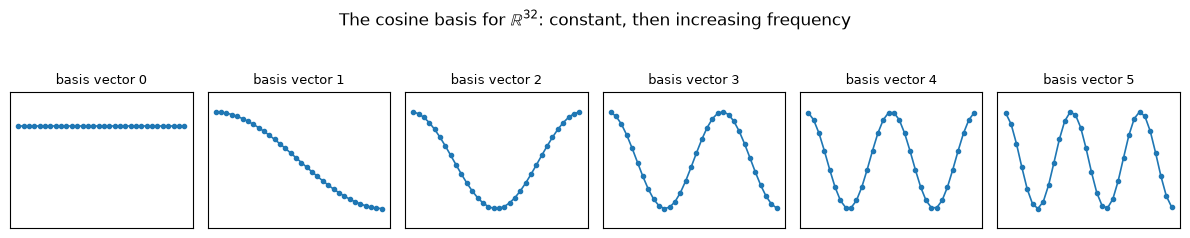

In [10]:
def dct_matrix(N):
    """Rows are the N orthonormal cosine basis vectors for R^N."""
    u = np.arange(N)[:, None]
    x = np.arange(N)[None, :]
    Cmat = np.cos((2 * x + 1) * u * np.pi / (2 * N))
    Cmat *= np.sqrt(2.0 / N)
    Cmat[0] *= np.sqrt(0.5)                          # the constant row gets 1/sqrt(N)
    return Cmat

N = 32                                               # <- knob: image side length
Cd = dct_matrix(N)
print("orthonormal (C @ C.T = I)?", np.allclose(Cd @ Cd.T, np.eye(N)))

fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for k, ax in enumerate(axes):
    ax.plot(Cd[k], "o-", ms=3, lw=1.2)
    ax.set_title(f"basis vector {k}", fontsize=9); ax.set_ylim(-0.35, 0.35)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The cosine basis for $\\mathbb{R}^{32}$: constant, then increasing frequency", y=1.06)
plt.tight_layout(); plt.show()

Compare the two bases as *pictures*. Each basis vector of the 2-D pixel basis is
a single lit dot; each basis vector of the 2-D cosine basis is a wave pattern
spread across the whole image.

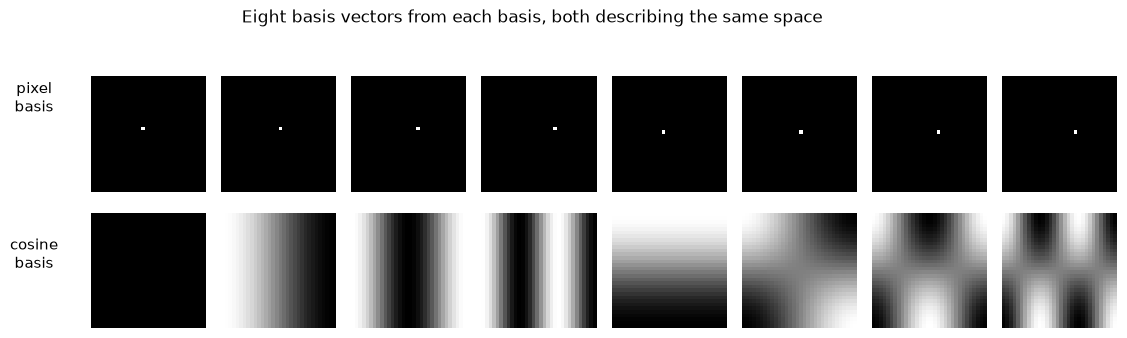

In [11]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for k, ax in enumerate(axes[0]):
    img = np.zeros((N, N)); img[k // 4 + 14, (k % 4) * 2 + 14] = 1.0
    ax.imshow(img, cmap="gray"); ax.axis("off")
axes[0, 0].set_ylabel("pixel", fontsize=10)
for k, ax in enumerate(axes[1]):
    uu, vv = k // 4, k % 4
    ax.imshow(np.outer(Cd[uu], Cd[vv]), cmap="gray"); ax.axis("off")
fig.text(0.085, 0.72, "pixel\nbasis", ha="center", fontsize=11)
fig.text(0.085, 0.26, "cosine\nbasis", ha="center", fontsize=11)
fig.suptitle("Eight basis vectors from each basis, both describing the same space", y=1.02)
plt.tight_layout(rect=[0.12, 0, 1, 1]); plt.show()

## IV.b The same photo, written twice

💻 **The code.** Take one 32×32 photograph, compute its coordinates in both
bases, and compare how the information is spread across the 1,024 numbers.

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


image shape: (32, 32)
exact round trip through the cosine basis: True


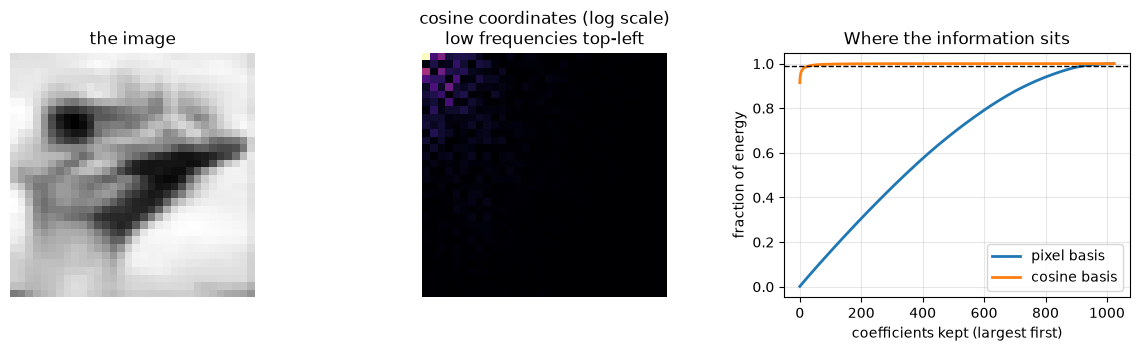

pixel basis :  924 of 1024 coefficients hold 99% of the energy
cosine basis:   32 of 1024 coefficients hold 99% of the energy


In [12]:
from datasets import load_dataset

cifar = load_dataset("uoft-cs/cifar10")
IMG_INDEX = 7                                              # <- knob: which photo
photo = np.array(cifar["train"][IMG_INDEX]["img"], dtype=np.float64).mean(axis=2) / 255.0

pixel_coords = photo                     # coordinates in the pixel basis ARE the image
cos_coords = Cd @ photo @ Cd.T           # coordinates in the cosine basis

# neither description loses anything: both are exact
print("image shape:", photo.shape)
print("exact round trip through the cosine basis:",
      np.allclose(Cd.T @ cos_coords @ Cd, photo))

def concentration(coords):
    """Fraction of total 'energy' held by the largest k coefficients, for every k."""
    e = np.sort(coords.ravel() ** 2)[::-1]
    return np.cumsum(e) / e.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].imshow(photo, cmap="gray"); axes[0].set_title("the image"); axes[0].axis("off")
axes[1].imshow(np.log1p(np.abs(cos_coords)), cmap="magma")
axes[1].set_title("cosine coordinates (log scale)\nlow frequencies top-left"); axes[1].axis("off")
for coords, label in [(pixel_coords, "pixel basis"), (cos_coords, "cosine basis")]:
    axes[2].plot(concentration(coords), lw=2, label=label)
axes[2].set_xlabel("coefficients kept (largest first)"); axes[2].set_ylabel("fraction of energy")
axes[2].axhline(0.99, color="k", ls="--", lw=1)
axes[2].legend(loc="lower right"); axes[2].grid(alpha=0.3)
axes[2].set_title("Where the information sits")
plt.tight_layout(); plt.show()

for coords, label in [(pixel_coords, "pixel basis "), (cos_coords, "cosine basis")]:
    k = int(np.searchsorted(concentration(coords), 0.99) + 1)
    print(f"{label}: {k:>4} of {photo.size} coefficients hold 99% of the energy")

The middle panel is the story in one picture: the cosine coordinates are bright
in the top-left corner, at the low frequencies, and essentially dark everywhere
else. The pixel coordinates have no such structure, because a photograph has no
unimportant pixels.

## IV.c Delete most of the numbers and look at what survives

The honest test of "a better description" is what happens when you throw most of
it away. Keep only the largest $k$ coordinates in each basis, zero the rest,
convert back to an image, and measure the error.

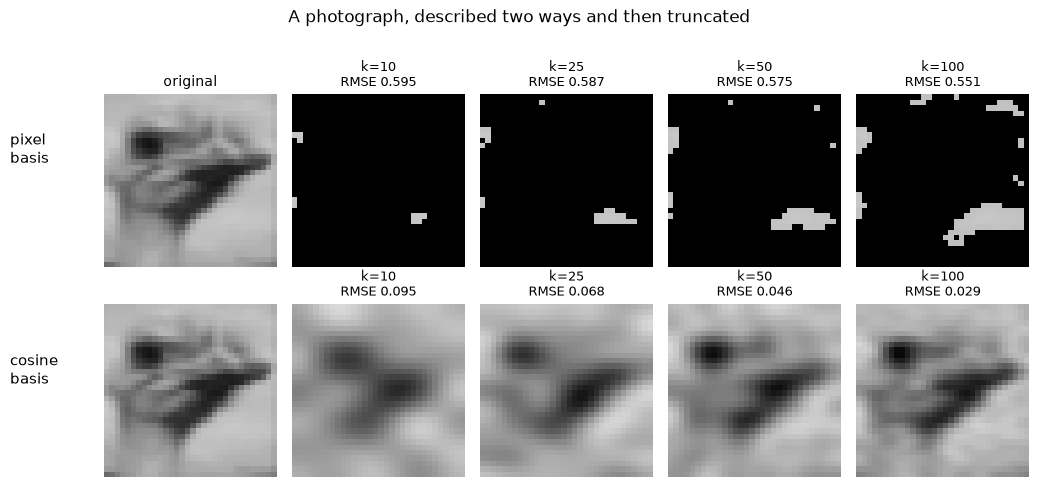

 k kept   pixel RMSE   cosine RMSE   cosine is
     10       0.5947        0.0949        6.3x better
     25       0.5874        0.0675        8.7x better
     50       0.5752        0.0459       12.5x better
    100       0.5507        0.0286       19.3x better


In [13]:
def keep_top_k(coords, k):
    """Zero out everything except the k largest-magnitude coefficients."""
    out = np.zeros_like(coords)
    idx = np.unravel_index(np.argsort(np.abs(coords).ravel())[::-1][:k], coords.shape)
    out[idx] = coords[idx]
    return out

KS = [10, 25, 50, 100]        # <- knob: how many of the 1024 numbers to keep

def compare_bases(image, basis, ks=KS, title=""):
    """Top-k reconstruction in the pixel basis vs the cosine basis."""
    coords_cos = basis @ image @ basis.T
    fig, axes = plt.subplots(2, len(ks) + 1, figsize=(2.1 * (len(ks) + 1), 4.8))
    for row in (0, 1):
        axes[row, 0].imshow(image, cmap="gray", vmin=0, vmax=1); axes[row, 0].axis("off")
    axes[0, 0].set_title("original", fontsize=10)

    errs = {}
    for j, k in enumerate(ks, start=1):
        recon = {"pixel":  keep_top_k(image, k),
                 "cosine": basis.T @ keep_top_k(coords_cos, k) @ basis}
        for row, name in enumerate(["pixel", "cosine"]):
            e = np.sqrt(np.mean((recon[name] - image) ** 2))
            errs.setdefault(name, []).append(e)
            axes[row, j].imshow(np.clip(recon[name], 0, 1), cmap="gray", vmin=0, vmax=1)
            axes[row, j].axis("off"); axes[row, j].set_title(f"k={k}\nRMSE {e:.3f}", fontsize=9)
    fig.text(0.015, 0.70, "pixel\nbasis", fontsize=11)
    fig.text(0.015, 0.24, "cosine\nbasis", fontsize=11)
    fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0.09, 0, 1, 1]); plt.show()

    print(f"{'k kept':>7}  {'pixel RMSE':>11}  {'cosine RMSE':>12}  {'cosine is':>10}")
    for k, ep, ec in zip(ks, errs["pixel"], errs["cosine"]):
        print(f"{k:>7}  {ep:>11.4f}  {ec:>12.4f}  {ep/ec:>9.1f}x better")
    return errs

_ = compare_bases(photo, Cd, title="A photograph, described two ways and then truncated")

**Same vector. Same space. Same number of coordinates thrown away. Very
different result.**

The pixel basis spends its budget on isolated bright dots and reconstructs
confetti, because in that basis the information genuinely is spread across all
1,024 numbers, with no most-important pixel. The cosine basis concentrates
almost everything into a few dozen low-frequency coefficients, so the same
budget buys a recognisable picture.

This is the practical meaning of the chapter's opening claim. Changing basis
moves no vectors and destroys no information; it changes only *which numbers are
worth keeping*. JPEG is this experiment, run on 8×8 blocks with a quantisation
step added.

## IV.d The counter-example: when the pixel basis is already good

It would be an easy over-generalisation to conclude that the cosine basis is
simply better. It is not. It is better *for photographs*, which are mostly
smooth. Run the identical experiment on a handwritten digit, where most of the
pixels are exactly zero.

fraction of exactly-zero pixels: photo 0.0%   digit 74.5%



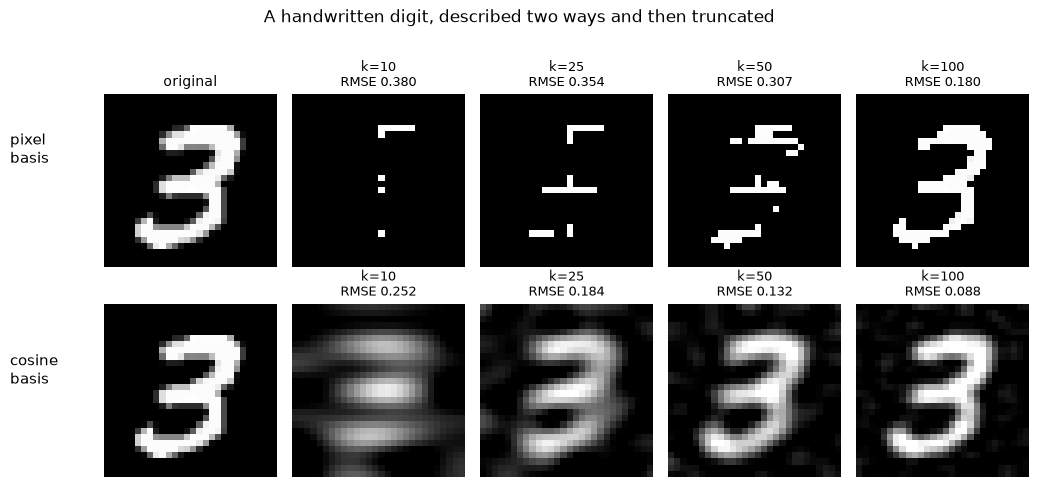

 k kept   pixel RMSE   cosine RMSE   cosine is
     10       0.3797        0.2518        1.5x better
     25       0.3541        0.1840        1.9x better
     50       0.3070        0.1320        2.3x better
    100       0.1805        0.0883        2.0x better


In [14]:
mnist = load_dataset("ylecun/mnist")
digit = np.array(mnist["train"][7]["image"], dtype=np.float64) / 255.0     # <- knob
Cd28 = dct_matrix(28)

print(f"fraction of exactly-zero pixels: photo {np.mean(photo == 0):.1%}"
      f"   digit {np.mean(digit == 0):.1%}\n")

_ = compare_bases(digit, Cd28, ks=[10, 25, 50, 100],
                  title="A handwritten digit, described two ways and then truncated")

The advantage collapses from an order of magnitude to roughly a factor of two,
and it collapses for a reason you can read off the zero-pixel counts printed
above. A digit is **already sparse in the pixel basis**, because most of its
coordinates are exactly zero, so discarding them costs nothing. The photograph
had no such gift, which is why it needed a change of basis to find one.

**There is no universally best basis.** There is only a best basis *for a given
collection of vectors*, and the cosine basis is a fixed formula that was never
told what it would be describing.

That observation is the seed of the last chapter of this course. **Chapter 9**
does not guess a basis. It computes the optimal one directly from a dataset, by
measurement, and on handwritten digits it beats both bases you just tried.

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| `basis_report` on four candidate sets | A basis is independent *and* spanning; three vectors in $\mathbb{R}^3$ can still fail |
| `address_test`: 100% reachable, unique | Basis $\iff$ every vector has exactly one address. Too few → no address; too many → many |
| 500 random bases of one plane, all size 2 | **Dimension** is a property of the space, not of the basis you happened to pick |
| A point with 3 components and 2 coordinates | Components describe the container; dimension describes the contents |
| $\mathbf{v} = B[\mathbf{v}]_B$, $[\mathbf{v}]_B = B^{-1}\mathbf{v}$ | $B$'s columns are the basis vectors, so $B$ converts *out of* the basis and $B^{-1}$ *into* it |
| One arrow drawn in two grids | Changing basis moves nothing. It re-labels everything |
| $Q^\top x$ beating `solve(G, x)` | Orthonormal bases make coordinates a dot product, which is the reason Chapter 7 exists |
| A photo truncated to 100 of 1,024 coefficients in each basis (19× apart) | The right description makes most of the numbers ignorable, and that is what compression *is* |
| The same test on a digit, where the gap nearly vanishes | There is no best basis, only a best basis *for your data*. Chapter 9 computes one |

**Where the course goes from here.** You now have the static half of linear
algebra: spaces, the sets that describe them, and the addresses they hand out.

The other half is motion. Chapter 4 takes up **linear transformations**,
functions between vector spaces that respect addition and scaling, and proves
the fact that makes matrices inevitable: *a linear transformation is completely
determined by what it does to a basis.* Every matrix you have ever seen is that
sentence, written down.